In [1]:
import pandas as pd
import os.path as op
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

bids_folder = '/Users/mrenke/data/ds-stressrisk'
supplements_path = '/Users/mrenke/Desktop/StressRisk/paper&abstracts/supplements'

sns.set_context('talk')
sns.set_theme('paper', 'white', font='helvetica', font_scale=1.5, palette='tab10')


In [2]:
import arviz as az
model_label = '5' # model where priors shift together 
idata = az.from_netcdf(op.join(bids_folder, 'derivatives', 'cogmodels', f'model-{model_label}_trace.netcdf'))

In [ ]:
def get_posterior(idata,param,regressor): # adpated version (before was only idata.posterior[param] and 'subject' was and addiotnal index, but that is not what we want here!)
    df = idata.posterior[param+'_mu'].to_dataframe()
    df.index = df.index.set_names(['chain','draw','regressor'])
    df = df.xs(regressor, 0,'regressor')
    return df
    
from bauer.utils.math import softplus_np

param_list = ['risky_prior_mu','safe_prior_mu','n1_evidence_sd','n2_evidence_sd','risky_prior_std','safe_prior_std'] # 'risky_prior_std'
results_list = []

for param in param_list:
    #print(f'\n{param}')
    p_int =  get_posterior(idata,param,'Intercept')
    param_name = param
    if 'prior_mu' in param: # for risky- & safe- prior_mus, any effect can only be mediated by a general 
        param = 'prior_mu'
    p_g0_s1 = p_int
    p_g0_s2 = p_int.values  + get_posterior(idata,param,'session')
    p_g1_s1 = p_int.values  + get_posterior(idata,param,'group')
    p_g1_s2 = p_int.values  + get_posterior(idata,param,'group') + get_posterior(idata,param,'session') + get_posterior(idata,param,'session:group')
        
    results = {'Group 0, Session 1': p_g0_s1, 'Group 0, Session 2': p_g0_s2,
        'Group 1, Session 1': p_g1_s1,'Group 1, Session 2': p_g1_s2}
    for key, values in results.items():
        values = softplus_np(values.values) if ('sd' in param or 'std' in param) else values.values
        ci = np.percentile(values, [2.5, 97.5])
        #print(f'{key}: Mean = {np.mean(values.values):.3f}, 95% CI = [{ci[0]:.3f}, {ci[1]:.3f}]')
        results_list.append([param_name, key, np.mean(values), ci[0], ci[1]])
df_results = pd.DataFrame(results_list, columns=['Parameter', 'Group/Session', 'Mean', 'CI Lower', 'CI Upper'])
df_results.set_index(['Parameter', 'Group/Session'])

Mean  CI Lower  CI Upper
Parameter       Group/Session                                   
risky_prior_mu  Group 0, Session 1  3.291343  2.993922  3.577278
                Group 0, Session 2  3.171644  2.945387  3.391746
                Group 1, Session 1  2.771165  2.411254  3.147748
                Group 1, Session 2  3.158895  2.803672  3.500723
safe_prior_mu   Group 0, Session 1  3.201961  2.713737  3.776340
                Group 0, Session 2  3.082262  2.638719  3.632946
                Group 1, Session 1  2.681782  2.116092  3.292029
                Group 1, Session 2  3.069513  2.526623  3.686832
n1_evidence_sd  Group 0, Session 1  0.283917  0.229173  0.349889
                Group 0, Session 2  0.252987  0.222020  0.287219
                Group 1, Session 1  0.298745  0.229232  0.381224
                Group 1, Session 2  0.283775  0.243687  0.328330
n2_evidence_sd  Group 0, Session 1  0.198643  0.161072  0.244184
                Group 0, Session 2  0.192698  0.168315  0.218998
                Group 1, Session 1  0.215563  0.167006  0.273226
                Group 1, Session 2  0.204021  0.172681  0.236092
risky_prior_std Group 0, Session 1  0.344085  0.239295  0.474368
                Group 0, Session 2  0.367670  0.278464  0.475519
                Group 1, Session 1  0.367770  0.245238  0.520930
                Group 1, Session 2  0.367460  0.269576  0.490742
safe_prior_std  Group 0, Session 1  0.415288  0.242060  0.664322
                Group 0, Session 2  0.601553  0.392841  0.886696
                Group 1, Session 1  0.523857  0.274750  0.859193
                Group 1, Session 2  0.678107  0.423307  1.051189

In [14]:
def get_posterior(idata,param,regressor): # adpated version (before was only idata.posterior[param] and 'subject' was and addiotnal index, but that is not what we want here!)
    df = idata.posterior[param+'_mu'].to_dataframe()
    df.index = df.index.set_names(['chain','draw','regressor'])
    df = df.xs(regressor, 0,'regressor')
    df['regressor'] = regressor
    return df

results_list = []
for param in ['risky_prior_std','safe_prior_std']:
    for regressor in ['session', 'session:group']:
        dif = get_posterior(idata,param,regressor).drop('regressor', axis=1).values
        ci_lower, ci_upper = np.percentile(dif, [2.5, 97.5])
        results_list.append([param, regressor, np.round(np.mean(dif>0),3), np.mean(dif), ci_lower, ci_upper])
        #print(f'{param} - {regressor}:  p={np.mean(dif>0):.3f}, mean={np.mean(dif):.3f}, 95%CI=[{ci_lower:.3f}, {ci_upper:.3f}]')

df_results = pd.DataFrame(results_list, columns=['Parameter', 'Regressor', 'P-val', 'Mean', 'CI Lower', 'CI Upper'])
df_results.set_index(['Parameter', 'Regressor']) # print(df_results.to_string(index=False))

P-val      Mean  CI Lower  CI Upper
Parameter       Regressor                                         
risky_prior_std session        0.768  0.084970 -0.137659  0.314362
                session:group  0.314 -0.079264 -0.395347  0.253085
safe_prior_std  session        0.996  0.482564  0.118309  0.936636
                session:group  0.337 -0.125639 -0.734145  0.479683

## Stress manipulation effect plots

In [54]:
from stress_risk.analyse_results.utils import get_stress_level
df_auc = get_stress_level().rename(mapper={'AUC':'cortisol_auc'}, axis=1).rename(mapper={'AUC':'cortisol_auc'}, axis=1)
df_stress_sr = pd.read_csv('/Users/mrenke/data/ds-stressrisk/addMeasures/selfRated_Stress.csv').rename(mapper={'mean_stress':'self-rated_auc'}, axis=1).set_index('subject')

df_comb = df_auc.join(df_stress_sr)#.set_index('group', append=True)
df_comb['group'] = df_comb['group'].astype(int)
df_comb['group'] = np.where(df_comb['group'] == 0, 'Control', 'Stress')
df_comb = df_comb.set_index('group',append=True)
df_comb.head()


,,cortisol_auc,self-rated_auc
subject,group,,
1,Control,2.060,6.981949
2,Control,-0.505,2.843103
3,Stress,3.530,7.110147
4,Stress,1.055,7.074323
5,Control,-0.635,2.557188


cortisol_auc: t=-5.349, p=0.000003
self-rated_auc: t=-4.550, p=0.000038


/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/seaborn/categorical.py:3370: UserWarning: 8.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/seaborn/categorical.py:3370: UserWarning: 8.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


Text(0, 25, 'Psychological stress level')

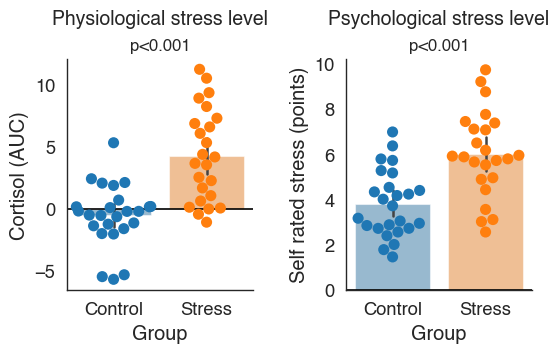

In [ ]:
from scipy.stats import ttest_ind

col_names = ['cortisol_auc', 'self-rated_auc']

fig, axs = plt.subplots(1, 2, figsize=(6,3))
for ax, column in zip(axs, col_names):
    sns.barplot(ax=ax, data=df_comb.reset_index(), x='group', y=column, hue='group',alpha=0.5, legend=False)
    sns.swarmplot(ax=ax, data=df_comb.reset_index(), x='group', y=column,  hue='group',size=8, legend=False)
    ax.axhline(0, c='black')
    t_stat, p_val = ttest_ind(df_comb.xs('Control',0,'group')[column], df_comb.xs('Stress',0,'group')[column])
    print(f'{column}: t={t_stat:.3f}, p={p_val:.6f}, ')
    #ax.set_title(f'\n p<{np.round(p_val,4)}') # {column} 
    ax.set_title(f'p<0.001', fontsize=12)

sns.despine()
fig.subplots_adjust(wspace=0.5)
axs[0].set(ylabel='Cortisol (AUC)', xlabel='Group')
axs[1].set(ylabel='Self rated stress (points)', xlabel='Group')
axs[0].annotate('Physiological stress level', xy=(0.5, 1), xytext=(0, 25),  xycoords='axes fraction', textcoords='offset points',size=14, ha='center', va='baseline',fontweight='bold')
axs[1].annotate('Psychological stress level', xy=(0.5, 1), xytext=(0, 25),  xycoords='axes fraction', textcoords='offset points',size=14, ha='center', va='baseline',fontweight='bold')